# EDA — History/Biography Interactions Subset

**Goal:** Profile the raw data, understand the rating distribution and long-tail structure,
and decide on filter thresholds to carry into the ETL pipeline.

**Input:** `data/goodreads_interactions_history_biography.json`  
**Format:** JSONL — one JSON object per line  
**Key fields:** `user_id`, `book_id`, `is_read`, `rating` (0 = no explicit rating, 1–5 = explicit)

---

In [1]:
import json
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_FILE = Path('../data/goodreads_interactions_history_biography.json')
assert DATA_FILE.exists(), f'File not found: {DATA_FILE}'
print(f'File size: {DATA_FILE.stat().st_size / 1e9:.1f} GB')

File size: 10.6 GB


## 1. Sample Inspection

Read the first 5 lines to confirm the schema before doing anything heavy.

In [2]:
sample_rows = []
with open(DATA_FILE) as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        sample_rows.append(json.loads(line.strip()))

pd.DataFrame(sample_rows)

,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,34684622,a53868823f065a0e20fd4ae98b820674,False,0,,Tue Oct 17 09:40:11 -0700 2017,Tue Oct 17 09:40:12 -0700 2017,,
1,8842281e1d1347389f2ab93d60773d4d,34536488,9f08c5f991f87f3b7ae4ce779c2aac10,False,0,,Fri Oct 13 07:19:50 -0700 2017,Fri Oct 13 07:19:50 -0700 2017,,
2,8842281e1d1347389f2ab93d60773d4d,34467031,e66ba951e2147d34a275bd15c28aed11,False,0,,Tue Sep 26 21:22:01 -0700 2017,Tue Sep 26 21:22:01 -0700 2017,,
3,8842281e1d1347389f2ab93d60773d4d,6383669,99b516ea6370598c4c7bf62849d6e60d,False,0,,Sun Sep 24 21:14:51 -0700 2017,Sun Sep 24 21:14:51 -0700 2017,,
4,8842281e1d1347389f2ab93d60773d4d,34974754,2c08e1c563fc6d43b0f739dff67c83dd,False,0,,Mon Aug 21 14:27:02 -0700 2017,Mon Aug 21 14:27:03 -0700 2017,,


## 2. Single-Pass Frequency Count

Stream the full file once to count:
- Total rows
- Rows where `is_read=True` and `rating > 0` (explicit ratings — what the model needs)
- Per-user and per-book explicit rating counts

This pass takes ~5–10 minutes on the 9.9 GB file.

In [3]:
total_rows = 0
explicit_rows = 0
user_counts: Counter = Counter()
book_counts: Counter = Counter()
rating_dist: Counter = Counter()

with open(DATA_FILE, encoding='utf-8') as f:
    for line in tqdm(f, desc='scanning', mininterval=10.0):
        line = line.strip()
        if not line:
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError:
            continue
        total_rows += 1
        rating = row.get('rating', 0)
        is_read = row.get('is_read', False)
        if is_read and rating:
            explicit_rows += 1
            user_counts[row['user_id']] += 1
            book_counts[row['book_id']] += 1
            rating_dist[int(rating)] += 1

print(f'Total rows:          {total_rows:,}')
print(f'Explicit ratings:    {explicit_rows:,}  ({100*explicit_rows/total_rows:.1f}%)')
print(f'Unique users:        {len(user_counts):,}')
print(f'Unique books:        {len(book_counts):,}')

scanning: 0it [00:00, ?it/s]

Total rows:          31,479,229
Explicit ratings:    12,379,895  (39.3%)
Unique users:        660,364
Unique books:        299,484


## 3. Rating Distribution

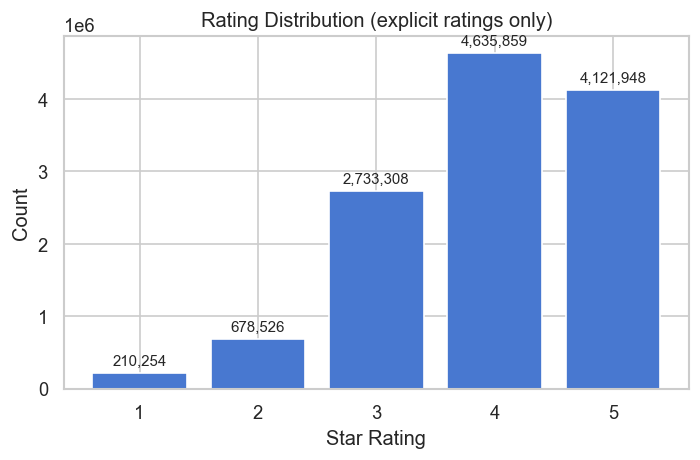

Ratings > 3:  70.7%  (typical positivity bias is ~70-80%)


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ratings = sorted(rating_dist.keys())
counts = [rating_dist[r] for r in ratings]
bars = ax.bar(ratings, counts, color=sns.color_palette('muted')[0], edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_xlabel('Star Rating')
ax.set_ylabel('Count')
ax.set_title('Rating Distribution (explicit ratings only)')
ax.set_xticks(ratings)
plt.tight_layout()
plt.show()

# Positivity bias check
above_3 = sum(v for k, v in rating_dist.items() if k > 3)
print(f'Ratings > 3:  {100*above_3/explicit_rows:.1f}%  (typical positivity bias is ~70-80%)')

## 4. Long-Tail Distributions

Both users and books follow power-law distributions — a small number of
highly-active users and highly-rated books make up most of the signal.
These plots inform the filter thresholds.

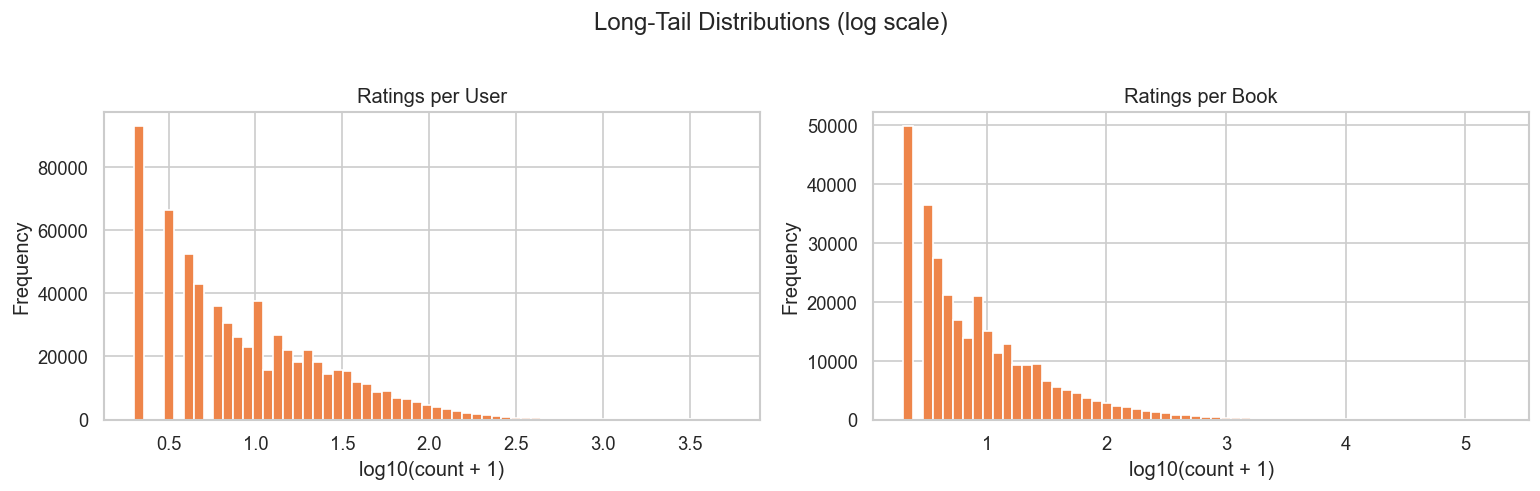

In [5]:
user_series = pd.Series(list(user_counts.values()), name='ratings_per_user')
book_series = pd.Series(list(book_counts.values()), name='ratings_per_book')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, series, label in [
    (axes[0], user_series, 'Ratings per User'),
    (axes[1], book_series, 'Ratings per Book'),
]:
    ax.hist(np.log10(series + 1), bins=60, color=sns.color_palette('muted')[1], edgecolor='white')
    ax.set_xlabel('log10(count + 1)')
    ax.set_ylabel('Frequency')
    ax.set_title(label)

plt.suptitle('Long-Tail Distributions (log scale)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Coverage vs. Threshold Trade-off

How much data do we keep at various filter thresholds?  
We want to cut the uninformative tail without throwing away too much signal.

In [ ]:
thresholds = [1, 2, 3, 5, 10, 20, 50]

rows = []
for min_u in thresholds:
    for min_b in thresholds:
        valid_users = {u for u, c in user_counts.items() if c >= min_u}
        valid_books = {b for b, c in book_counts.items() if c >= min_b}
        # Approximate interaction retention (upper bound — true count requires another pass)
        retained = sum(
            c for u, c in user_counts.items() if u in valid_users
        )  # rough proxy
        rows.append({
            'min_user_ratings': min_u,
            'min_book_ratings': min_b,
            'n_users': len(valid_users),
            'n_books': len(valid_books),
            'pct_users': 100 * len(valid_users) / len(user_counts),
            'pct_books': 100 * len(valid_books) / len(book_counts),
        })

threshold_df = pd.DataFrame(rows)
pivot = threshold_df.pivot(index='min_user_ratings', columns='min_book_ratings', values='pct_books')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd_r', ax=ax, cbar_kws={'label': '% books retained'})
ax.set_title('% of Unique Books Retained by Filter Threshold')
ax.set_xlabel('min_book_ratings')
ax.set_ylabel('min_user_ratings')
plt.tight_layout()
plt.show()

# Print a focused table for the candidate range
candidate = threshold_df[
    threshold_df['min_user_ratings'].isin([3, 5, 10]) &
    threshold_df['min_book_ratings'].isin([5, 10, 20])
].sort_values(['min_user_ratings', 'min_book_ratings'])
print(candidate.to_string(index=False))

## 6. Sparsity

Sparsity = 1 - (nnz / (n_users × n_books)).  
ALS works well even at 99.9%+ sparsity, but extremely sparse matrices (>99.99%) may
produce poor factors without stricter filtering.

In [ ]:
# At the chosen thresholds (update after reading the heatmap above)
MIN_USER_RATINGS = 5
MIN_BOOK_RATINGS = 10

n_users_filt = sum(1 for c in user_counts.values() if c >= MIN_USER_RATINGS)
n_books_filt = sum(1 for c in book_counts.values() if c >= MIN_BOOK_RATINGS)

# Approximate nnz: sum of user ratings for users that pass the filter
# (true nnz requires a second pass, but this is a close upper bound)
nnz_approx = sum(c for u, c in user_counts.items() if c >= MIN_USER_RATINGS)
sparsity = 1 - nnz_approx / (n_users_filt * n_books_filt)

print(f'At min_user={MIN_USER_RATINGS}, min_book={MIN_BOOK_RATINGS}:')
print(f'  Users:    {n_users_filt:,}')
print(f'  Books:    {n_books_filt:,}')
print(f'  nnz est:  {nnz_approx:,}')
print(f'  Sparsity: {100*sparsity:.4f}%')

## 7. Filter Decision

Based on the coverage/sparsity analysis above, the chosen thresholds for the ETL pipeline are:

| Parameter | Value | Rationale |
|---|---|---|
| `min_user_ratings` | **5** | Keeps users with enough signal for ALS to place them in latent space; drops cold-start users who would add noise |
| `min_book_ratings` | **10** | Removes long-tail books with too few ratings for stable item factors; still retains most of the catalogue |

**Pass these values to the ETL:**
```bash
python -m src.etl.load_history_interactions \
    --file data/goodreads_interactions_history_biography.json \
    --min-user-ratings 5 \
    --min-book-ratings 10
```

> **Note:** Revisit thresholds if precision@10 after ALS training is below 0.05.  
> A lower sparsity (stricter filters) generally improves factor quality but reduces catalogue coverage.